In [19]:
from rbfPUCurlNoise.triang_mesh import TriMesh, refine_mesh_1to4
from rbfPUCurlNoise.patches       import PatchCoverage
from rbfPUCurlNoise.rbf           import RBF
from rbfPUCurlNoise.interpolator  import PUMInterpolator
import triangle
from rbfPUCurlNoise.utils import plot_mesh
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def u_exact(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def du_dx_exact(x, y):
    return np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)

def du_dy_exact(x, y):
    return np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)

-375.08 359.5
-1.0 1.0


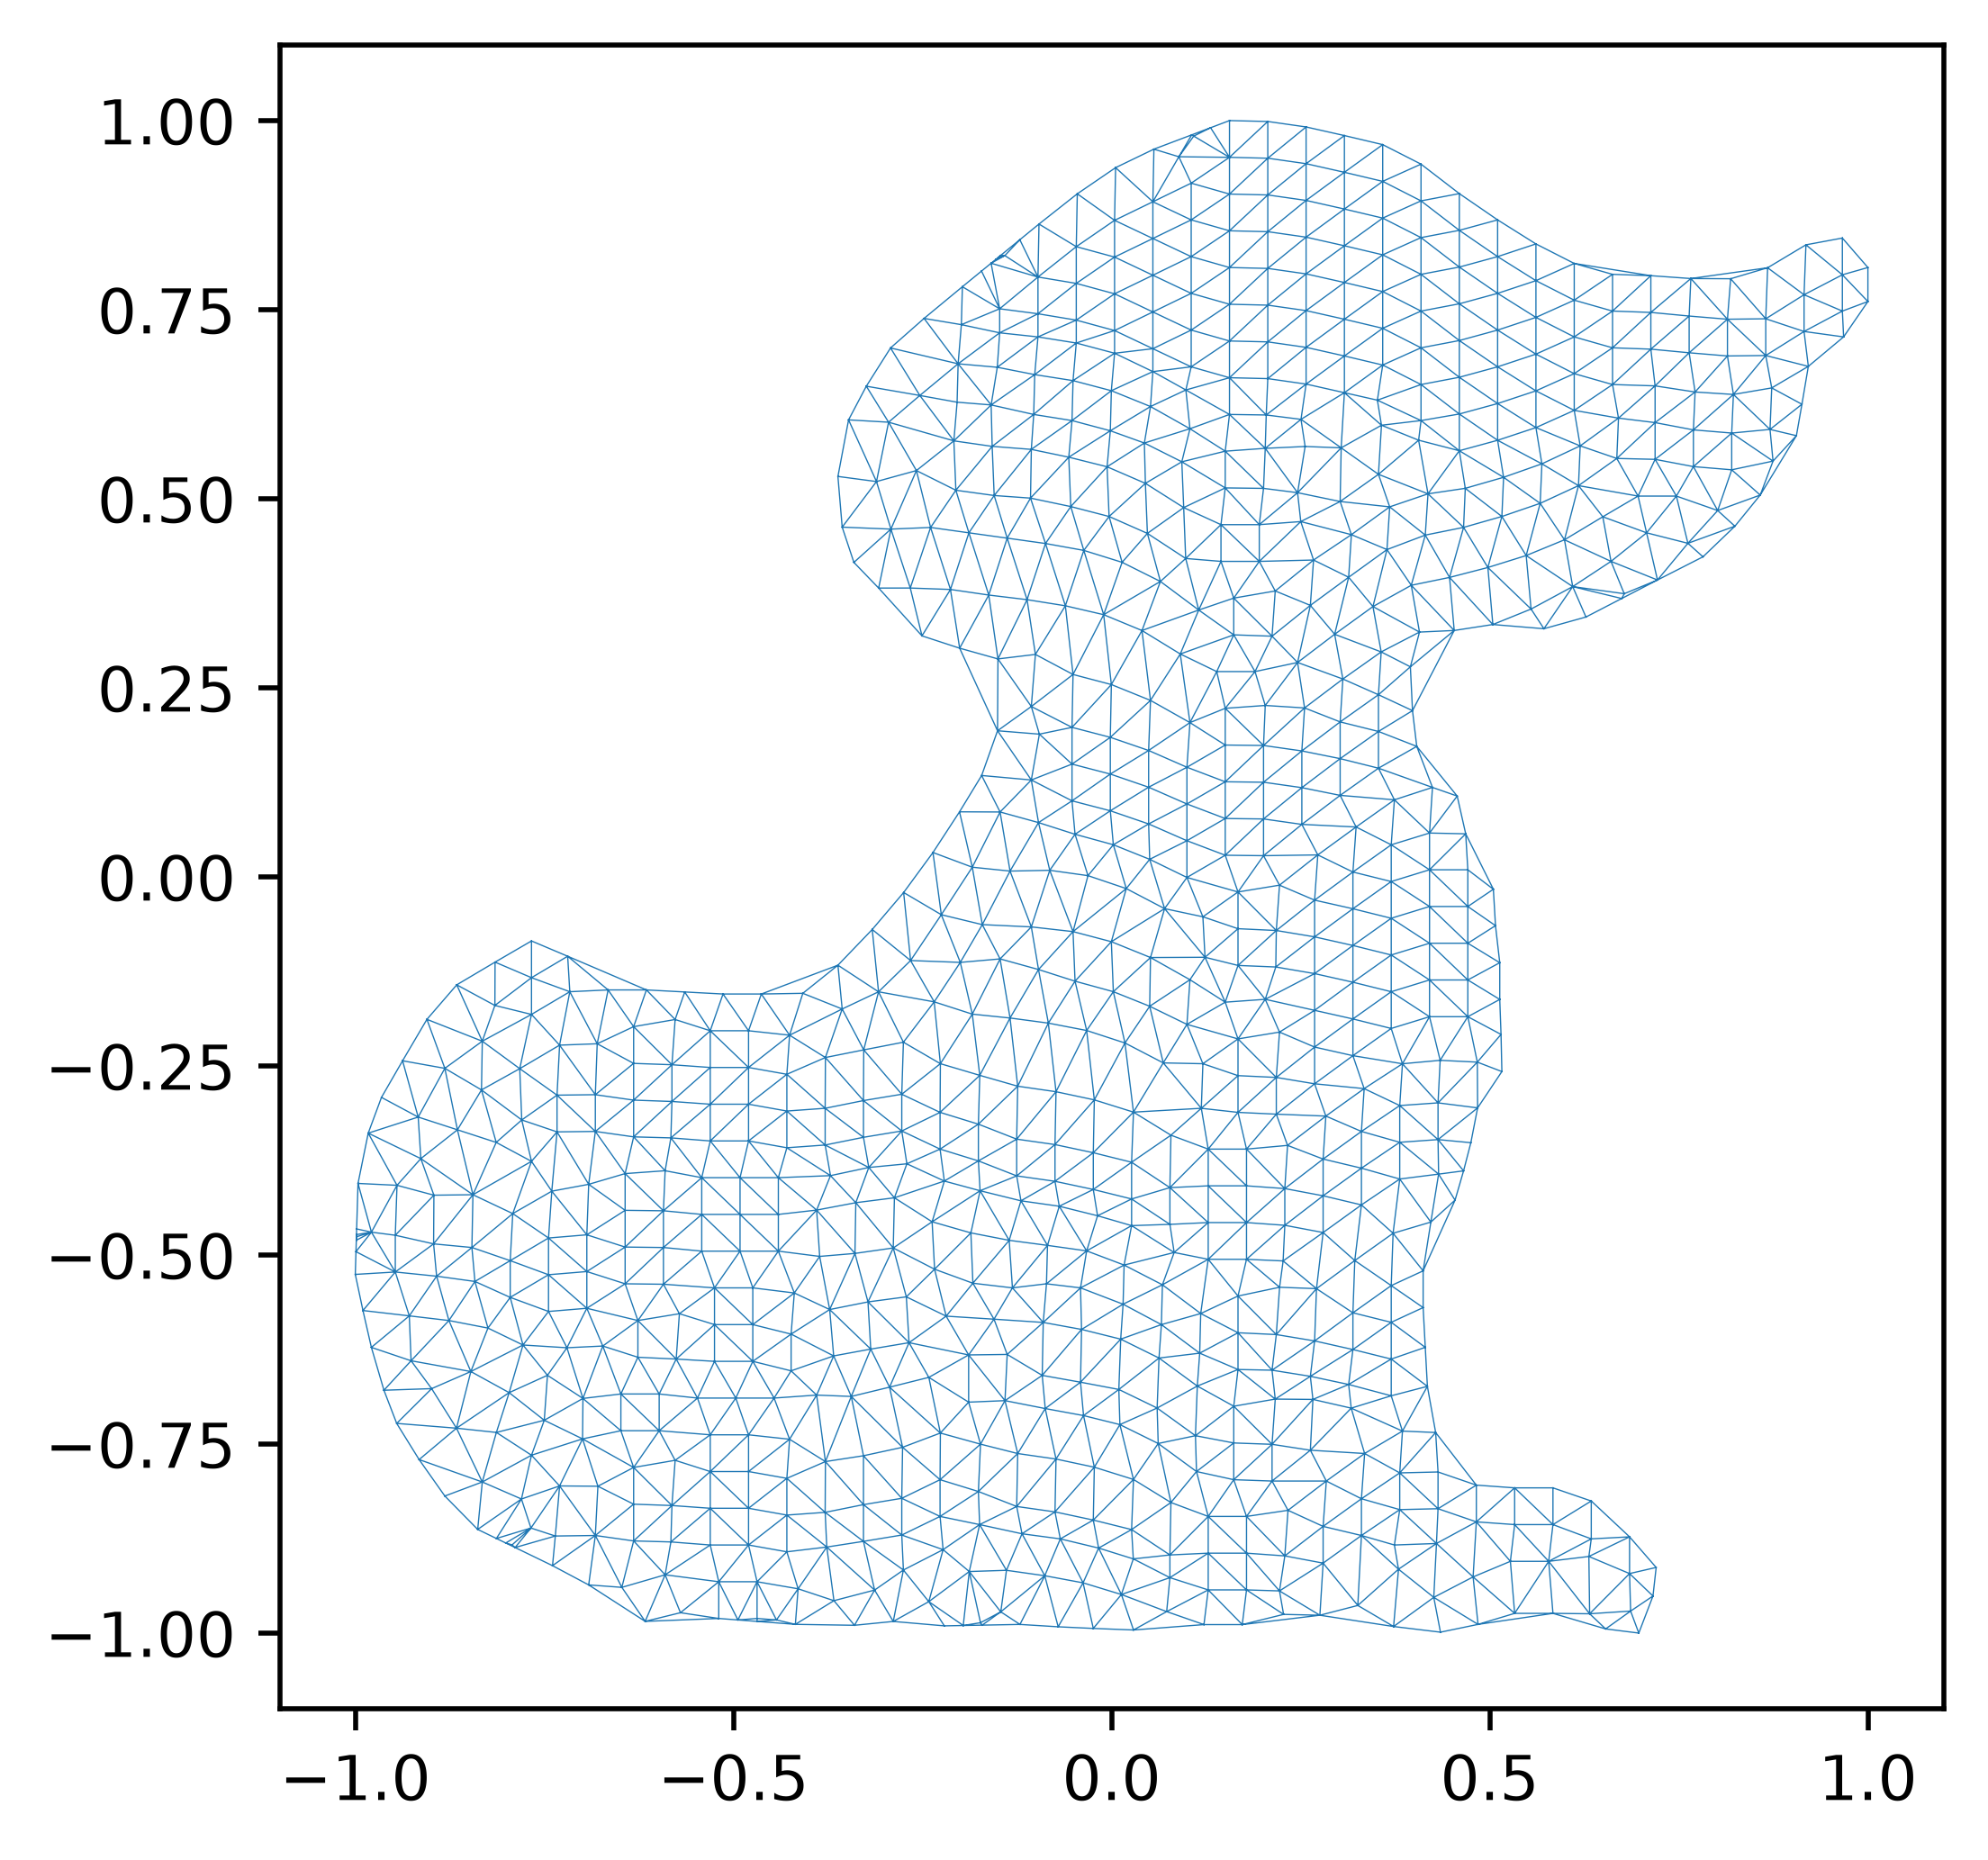

In [21]:
dog = triangle.load("../meshes/triangle_files", "dog")
dog_mesh = triangle.triangulate(dog, "pq5a150")

print(dog_mesh["vertices"].min(), dog_mesh["vertices"].max())
mins = dog_mesh["vertices"].min(axis=0)
maxs = dog_mesh["vertices"].max(axis=0)


# Normalizing mesh vertices range
dog_mesh["vertices"] = 2 * (dog_mesh["vertices"] - mins) / (maxs - mins) - 1
print(dog_mesh["vertices"].min(), dog_mesh["vertices"].max())

dog_mesh_obj = TriMesh(dog_mesh)
plot_mesh(dog_mesh)

In [22]:
coarse_scalar_field = u_exact(dog_mesh["vertices"][:,0], dog_mesh["vertices"][:,1])

coverage = PatchCoverage(dog_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

radius = np.mean(coverage.radius_list)
print(radius)
#epsilon = 1.0*radius
#print(epsilon)

pu_interpolator = PUMInterpolator(dog_mesh_obj, coverage, RBF(epsilon=1.0))
pu_interpolator.fit(coarse_scalar_field)

# Malha refinada para interpolar o campo escalar
pts, tri  = refine_mesh_1to4(dog_mesh["vertices"], dog_mesh["triangles"])
dog_mesh_fine = {}
dog_mesh_fine["vertices"] = pts
dog_mesh_fine["triangles"] = tri
dog_mesh_fine_obj = TriMesh(dog_mesh_fine)

fine_scalar_field = pu_interpolator.evaluate(dog_mesh_fine["vertices"] )
grad_x, grad_y = pu_interpolator.gradient(dog_mesh_fine["vertices"] )

grad_x_analytic = du_dx_exact(dog_mesh_fine["vertices"][:,0], dog_mesh_fine["vertices"][:,1])
grad_y_analytic = du_dy_exact(dog_mesh_fine["vertices"][:,0], dog_mesh_fine["vertices"][:,1])


curl_interpolated = np.hstack((-grad_y.reshape(-1,1), grad_x.reshape(-1,1)))
curl_exact = np.hstack((-grad_y_analytic.reshape(-1,1), grad_x_analytic.reshape(-1,1)))

mag_interp = np.sqrt((-grad_y)**2 + grad_x**2)
mag_exact = np.sqrt((-grad_y_analytic)**2 + grad_x_analytic**2)
diff = np.abs(mag_exact - mag_interp)

print(np.min(diff))
print(np.max(diff))

dog_mesh_fine_obj.save_mesh_paraview(dog_mesh_fine, vels=curl_interpolated, phi=mag_interp, psi=diff, out_name="dog_curl_interp.vtu")
dog_mesh_fine_obj.save_mesh_paraview(dog_mesh_fine, vels=curl_exact, phi=mag_exact, psi=diff, out_name="dog_curl_exact.vtu")


144
187
158
122
168
182
35
102
181
73
183
109

Coverage Summary:
  n_patches           : 11
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 73
  max_nodes           : 223
  mean_nodes          : 159.8181818181818
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 1.9775028121484814
  full_coverage       : True
0.4242640687119285
6.010457909155775e-09
0.18690932152593587


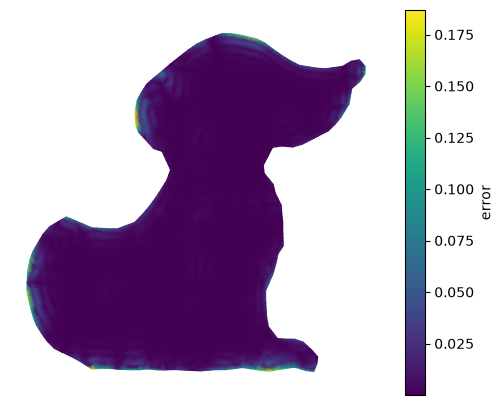

In [23]:
import matplotlib.tri as tri

x = dog_mesh_fine["vertices"][:,0]
y = dog_mesh_fine["vertices"][:,1]

triang = tri.Triangulation(
    x,
    y,
    dog_mesh_fine["triangles"]
)

fig, ax = plt.subplots(figsize=(6,5))

pc = ax.tripcolor(
    triang,
    diff,
    shading='gouraud',
    cmap='viridis'
)

plt.colorbar(pc, ax=ax,
             label=r"error")

ax.set_aspect("equal")
plt.axis('off')
plt.savefig(
    "error_magn.pdf",
    dpi=600,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()

